In [1]:
import pandas as pd
import sqlite3
import numpy as np
import os


caminho_db = os.path.join(os.getcwd(), '..', 'data', 'chamados.db')

with sqlite3.connect(caminho_db) as conexao:
    query = 'SELECT * FROM chamados'
    df = pd.read_sql_query(query,conexao)

display(df)
display(df.info())
display(df.describe())

,id_registro,nome_completo,plano,estado,cidade,consumo_Gb,mensalidade,status,inadimplencia
0,1,Marlon Monteiro,basico,Minas Gerais,Governador Valadares,24,70,ativo,não
1,2,Taís Tavares,basico,Minas Gerais,Contagem,28,70,ativo,não
2,3,Caroline Lopes,plus,Rio De Janeiro,Duque de Caxias,309,240,ativo,sim
3,4,Danielle Santos,basico,São Paulo,Sorocaba,37,70,inativo,não
4,5,Fabio Araujo,basico,Minas Gerais,Uberlandia,37,70,ativo,não
...,...,...,...,...,...,...,...,...,...
19995,19996,Davi Fagundes,basico,Rio De Janeiro,Nova Iguaçu,17,70,ativo,não
19996,19997,Ricardo Pinto,premium,Minas Gerais,Uberaba,77,120,inativo,não
19997,19998,Maria Brito,basico,Minas Gerais,Ipatinga,18,70,ativo,não
19998,19999,Lorena Guimarães,premium,Rio De Janeiro,Petrópolis,94,120,inativo,não


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id_registro    20000 non-null  int64
 1   nome_completo  20000 non-null  str  
 2   plano          20000 non-null  str  
 3   estado         20000 non-null  str  
 4   cidade         20000 non-null  str  
 5   consumo_Gb     20000 non-null  int64
 6   mensalidade    20000 non-null  int64
 7   status         20000 non-null  str  
 8   inadimplencia  20000 non-null  str  
dtypes: int64(3), str(6)
memory usage: 2.4 MB


None

,id_registro,consumo_Gb,mensalidade
count,20000.000000,20000.000000,20000.000000
mean,10000.500000,115.961000,142.225500
std,5773.647028,100.981926,70.872867
min,1.000000,15.000000,70.000000
25%,5000.750000,34.000000,70.000000
50%,10000.500000,74.000000,120.000000
75%,15000.250000,198.000000,240.000000
max,20000.000000,350.000000,240.000000


In [2]:
#analise
#qual plano mais vende
df_planos = df.groupby('plano')['mensalidade'].sum().sort_values(ascending=False).reset_index()
#quantia de clientes por plano
df_clientes_plano = df.groupby('plano').size().sort_values(ascending=False).reset_index(name='quantia de clientes')
#quantia de inadimplentes
df_inadimplencia = df.groupby(['plano','inadimplencia']).size().unstack(fill_value=0)
#consumo de internet entre clientes ativos e inativos
df_consumo = df.groupby('status')['consumo_Gb'].mean().reset_index()
#estados mais inadimplentes
df_estados_inadimplentes = df.groupby(['estado','inadimplencia']).size().sort_values(ascending=False).unstack(fill_value=0)
#desperdicio de banda
df_desperdicio = df.groupby('plano')['consumo_Gb'].agg(['min','max']).reset_index()
display(df_planos)
display(df_clientes_plano)
display(df_inadimplencia)
display(df_consumo)
display(df_estados_inadimplentes)
display(df_desperdicio)




,plano,mensalidade
0,plus,1559520
1,premium,815640
2,basico,469350


,plano,quantia de clientes
0,premium,6797
1,basico,6705
2,plus,6498


inadimplencia,não,sim
plano,,
basico,4868,1837
plus,4753,1745
premium,4944,1853


,status,consumo_Gb
0,ativo,116.053785
1,inativo,115.757348


inadimplencia,não,sim
estado,,
Minas Gerais,4927,1762
Rio De Janeiro,4801,1855
São Paulo,4837,1818


,plano,min,max
0,basico,15,40
1,plus,150,350
2,premium,50,100


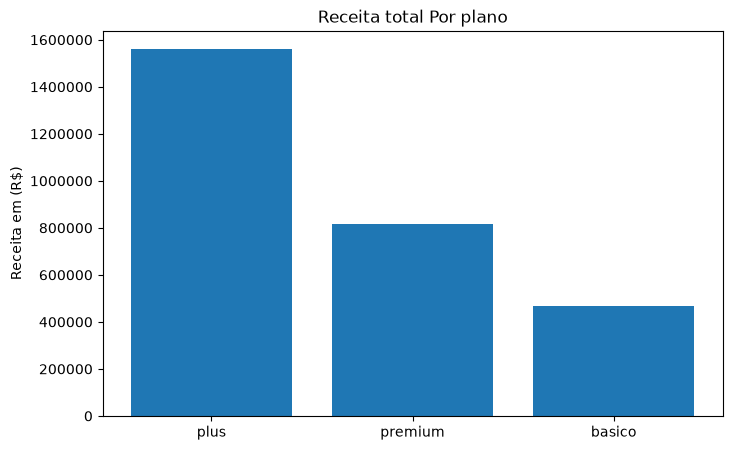

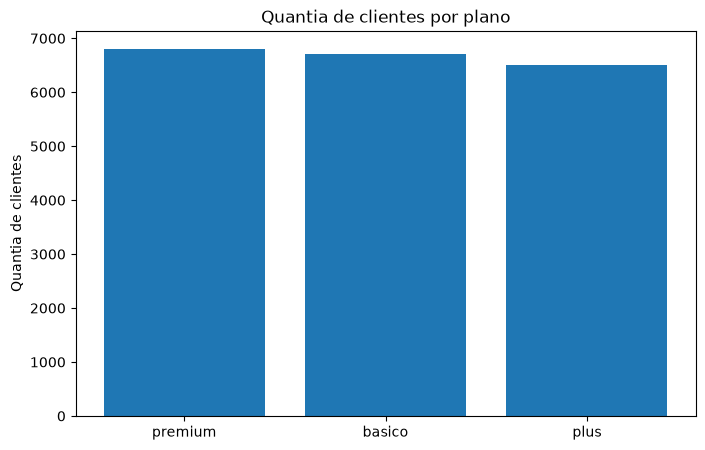

<Figure size 800x600 with 0 Axes>

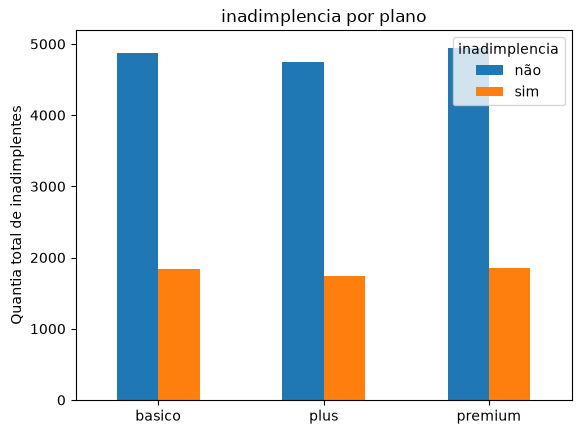

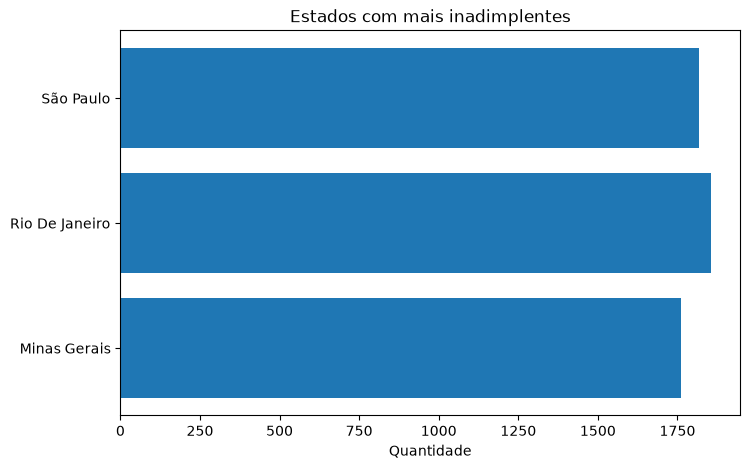

In [ ]:
#graficos
import matplotlib.pyplot as plt

#renda total por plano
plt.figure(figsize=(8, 5))
plt.bar(df_planos['plano'], df_planos['mensalidade'])
plt.title('Receita total Por plano')
plt.xlabel('')
plt.ylabel('Receita em (R$)')
plt.ticklabel_format(style='plain',axis='y')
plt.show()


#quantia de clientes total por plano
plt.figure(figsize=(8,5))
plt.bar(df_clientes_plano['plano'],df_clientes_plano['quantia de clientes'])
plt.title('Quantia de clientes por plano')
plt.xlabel('')
plt.ylabel('Quantia de clientes')
plt.ticklabel_format(style='plain', axis='y')


#taxa de inadimplencia por plano
plt.figure(figsize=(8,6))
df_inadimplencia.plot(kind='bar', stacked=False)
plt.title('inadimplencia por plano')
plt.xlabel('')
plt.ylabel('Quantia total de inadimplentes')
plt.xticks(rotation=0)
plt.show()


# estados mais inadimplentes
plt.figure(figsize=(8, 5))
plt.barh(df_estados_inadimplentes.index, df_estados_inadimplentes['sim'])
plt.title('Estados com mais inadimplentes')
plt.xlabel('Quantidade')
plt.show()



